# Analysis of the relationship between deprivation and early years performance in England

This notebook investigates the relationship between area-level deprivation and school readiness in England. School readiness is measured by the percentage of children achieving a Good Level of Development (GLD) in the Early Years Foundation Stage Profile (EYFSP) at the end of Reception (age 4–5). Deprivation is measured using the Index of Multiple Deprivation (IMD) 2019.

After establishing the main deprivation–GLD relationship, we look at whether early years provision factors (childcare take-up, Ofsted quality, SEN support) can explain any of the remaining variance — i.e., why some districts do better or worse than their deprivation would predict.

### Imports

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
from scipy.stats import zscore
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from config import DATABASE_PATH, PROJECT_ROOT

### Gather data

First, we need to check whether both datasets (EYFSP and IMD) have the same local authority districts (LADs) and whether there are any mismatches in the LAD codes or names between the two datasets. This is crucial to ensure that we can accurately link the EYFSP performance data with the corresponding deprivation data from the IMD.

In [2]:
# Check for mismatches between EYFSP and IMD data

# -- Left join EYFSP to IMD to find EYFSP records without a match in IMD
query = ("select eyfsp.lad_code, eyfsp.lad_name, imd.la_code, imd.la_name "
         "from eyfsp "
         "left join imd on eyfsp.lad_code = imd.la_code "
         "where imd.la_code is NULL")
with sqlite3.connect(DATABASE_PATH) as conn:
    eyfsp_join = pd.read_sql_query(query, conn)

# -- Left join IMD to EYFSP to find IMD records without a match in EYFSP
query = ("select eyfsp.lad_code, eyfsp.lad_name, imd.la_code, imd.la_name "
         "from imd "
         "left join eyfsp on imd.la_code = eyfsp.lad_code "
         "where eyfsp.lad_code is NULL")
with sqlite3.connect(DATABASE_PATH) as conn:
    imd_join = pd.read_sql_query(query, conn)

if eyfsp_join.empty and imd_join.empty:
    print("No mismatches between EYFSP and IMD data.")
else:
    print("Mismatches found between EYFSP and IMD data:")
    print(f"EYFSP districts without IMD matches:\n{eyfsp_join.lad_name.unique()}")
    print(f"IMD districts without EYFSP matches:\n{imd_join.la_name.unique()}")

Mismatches found between EYFSP and IMD data:
EYFSP districts without IMD matches:
<StringArray>
[                             nan,                     'Cumberland',
        'Westmorland and Furness',                       'Barnsley',
                'North Yorkshire',                      'Sheffield',
         'North Northamptonshire',          'West Northamptonshire',
                'Buckinghamshire',                       'Somerset',
 'Outside of England and unknown']
Length: 11, dtype: str
IMD districts without EYFSP matches:
<StringArray>
[        'Aylesbury Vale',               'Chiltern',            'South Bucks',
                'Wycombe',                  'Corby',               'Daventry',
  'East Northamptonshire',              'Kettering',            'Northampton',
 'South Northamptonshire',         'Wellingborough']
Length: 11, dtype: str


These mismatches are likely due to local government restructuring between 2019 (when the IMD was published) and 2021–2025 (the EYFSP data). Let's count how many districts are matched vs unmatched to understand the scale of the issue.

In [3]:
# Count matched vs unmatched districts
query = """
    select count(distinct eyfsp.lad_code) as total_eyfsp_districts
    from eyfsp
    where geographic_level = 'Local authority district'
      and lad_code != 'z'
      and lad_code is not null
"""
with sqlite3.connect(DATABASE_PATH) as conn:
    total = pd.read_sql_query(query, conn).iloc[0, 0]

query = """
    select count(distinct eyfsp.lad_code) as matched_districts
    from eyfsp
    inner join imd on eyfsp.lad_code = imd.la_code
    where eyfsp.geographic_level = 'Local authority district'
"""
with sqlite3.connect(DATABASE_PATH) as conn:
    matched = pd.read_sql_query(query, conn).iloc[0, 0]

print(f"Matched {matched} of {total} EYFSP districts ({matched/total:.0%}) to IMD records.")
print(f"Dropped {total - matched} districts due to restructuring or code changes.")

Matched 306 of 315 EYFSP districts (97%) to IMD records.
Dropped 9 districts due to restructuring or code changes.


A 3% loss is minimal - we can proceed with the matched districts without remapping. The unmatched districts are dropped via an inner join.

In [4]:
with open(Path(PROJECT_ROOT / "sql" / "EYFSP_and_IMD.sql")) as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df = pd.read_sql_query(query, conn, params=[202425])

print(df)

      lad_code              lad_name  children_count  gld_children_count  \
0    E06000047         County Durham            4861                3163   
1    E06000005            Darlington            1132                 735   
2    E08000037             Gateshead            1912                1271   
3    E06000001            Hartlepool            1024                 666   
4    E06000002         Middlesbrough            1794                1106   
..         ...                   ...             ...                 ...   
282  E09000024                Merton            1951                1386   
283  E09000026             Redbridge            4009                2923   
284  E09000027  Richmond upon Thames            2156                1661   
285  E09000029                Sutton            2452                1716   
286  E09000031        Waltham Forest            3211                2404   

     gld_children_percent  imd_score  
0               65.068915     26.793  
1        

Check for missing data and correct data types to ensure the data is clean and ready for analysis.

In [5]:
# Check for missing IMD scores

if df["imd_score"].isna().any():
    # Check how many records have missing IMD scores
    missing_count = df["imd_score"].isna().sum()
    total_count = len(df)
    print(f"Warning: {missing_count} out of {total_count} records have missing")
elif df["gld_children_percent"].isna().any():
    missing_count = df["gld_children_percent"].isna().sum()
    total_count = len(df)
    print(f"Warning: {missing_count} out of {total_count} records have missing GLD percentages.")
else:
    print("No missing data found.")


No missing data found.


In [6]:
# Check data types and adjust where necessary
print(f"Data type of imd_score: {df['imd_score'].dtype}")
print(f"Data type of gld_children_percent: {df['gld_children_percent'].dtype}")
print(f"Data type of gld_children_count: {df['gld_children_count'].dtype}")

Data type of imd_score: float64
Data type of gld_children_percent: float64
Data type of gld_children_count: int64


### Part 1: Deprivation and school readiness

We z-score both variables so that regression coefficients are in standard deviation units, making them easier to interpret. We use weighted least squares (WLS), weighting each district by its number of children.

In [7]:
cols_to_standardise = ["imd_score", "gld_children_percent"]
df[cols_to_standardise] = df[cols_to_standardise].apply(zscore)

X = df["imd_score"]
y = df["gld_children_percent"]

if len(X) != len(y):
    raise ValueError("Mismatched lengths between features and target variable.")

print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

model_imd = sm.WLS(y, sm.add_constant(X), weights=df["children_count"]).fit()
print(model_imd.summary())


Shape of X: (287,), Shape of y: (287,)
                             WLS Regression Results                             
Dep. Variable:     gld_children_percent   R-squared:                       0.506
Model:                              WLS   Adj. R-squared:                  0.505
Method:                   Least Squares   F-statistic:                     292.3
Date:                  Thu, 28 May 2026   Prob (F-statistic):           1.38e-45
Time:                          17:39:53   Log-Likelihood:                -310.86
No. Observations:                   287   AIC:                             625.7
Df Residuals:                       285   BIC:                             633.0
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

Text(0.5, 1.0, 'School Readiness vs Deprivation (2024/25)')

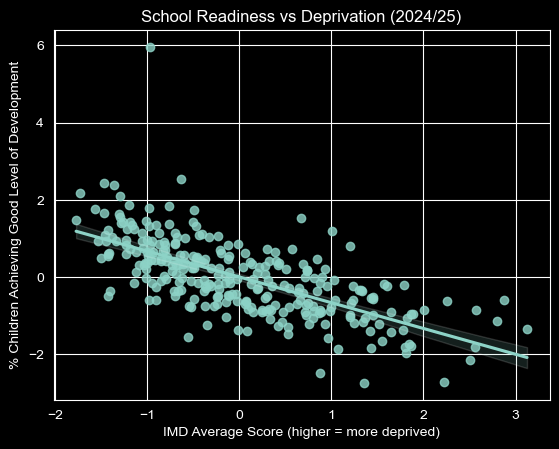

In [8]:
ax = sns.regplot(df, x="imd_score", y="gld_children_percent")
ax.set_xlabel("IMD Average Score (higher = more deprived)")
ax.set_ylabel("% Children Achieving Good Level of Development")
ax.set_title("School Readiness vs Deprivation (2024/25)")

<Axes: xlabel='imd_score', ylabel='gld_children_percent'>

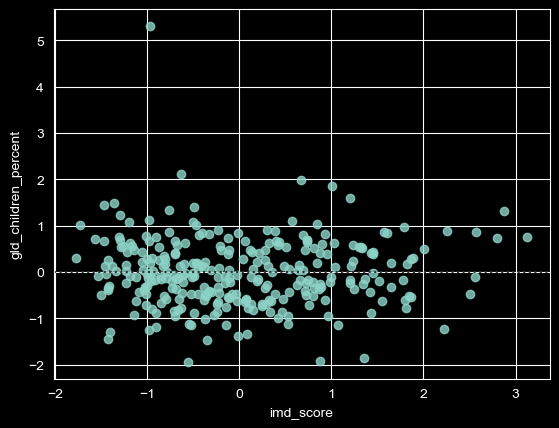

In [9]:
sns.residplot(df, x="imd_score", y="gld_children_percent")

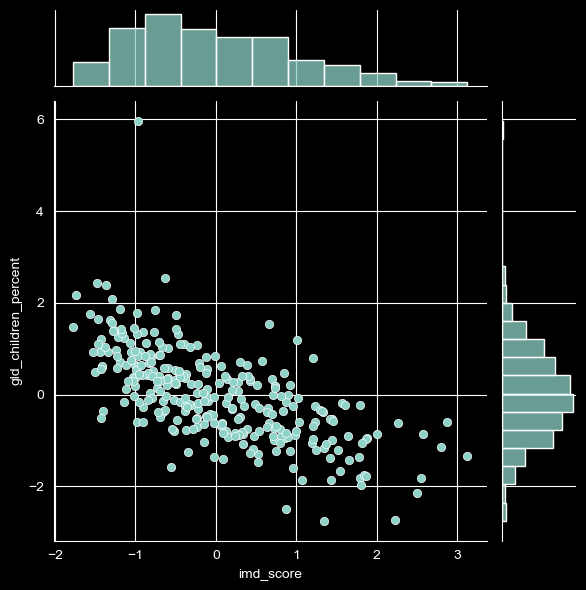

In [10]:
sns.jointplot(df, x="imd_score", y="gld_children_percent")

In [11]:
px.scatter(df, x="imd_score", y="gld_children_percent", hover_name="lad_name", trendline="ols")

### Part 1a: Which aspects of deprivation matter?

In [12]:
with open(Path(PROJECT_ROOT / "sql" / "EYFSP_and_IOD.sql")) as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df_iod = pd.read_sql_query(query, conn, params=[202425])

print(df_iod)

      lad_code              lad_name  children_count  gld_children_count  \
0    E06000047         County Durham            4861                3163   
1    E06000005            Darlington            1132                 735   
2    E08000037             Gateshead            1912                1271   
3    E06000001            Hartlepool            1024                 666   
4    E06000002         Middlesbrough            1794                1106   
..         ...                   ...             ...                 ...   
282  E09000024                Merton            1951                1386   
283  E09000026             Redbridge            4009                2923   
284  E09000027  Richmond upon Thames            2156                1661   
285  E09000029                Sutton            2452                1716   
286  E09000031        Waltham Forest            3211                2404   

     gld_children_percent  employment_score  education_score  health_score  \
0        

In [13]:
iod_measure_names = ["employment_score", "education_score", "health_score", "crime_score", "barriers_score", "living_score", "idaci_score"]
cols_to_standardise = ["gld_children_percent"] + iod_measure_names
df_iod[cols_to_standardise] = df_iod[cols_to_standardise].apply(zscore)

X = df_iod[iod_measure_names]
y = df_iod["gld_children_percent"]

if len(X) != len(y):
    raise ValueError("Mismatched lengths between features and target variable.")

print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

model_iod = sm.WLS(y, sm.add_constant(X), weights=df_iod["children_count"]).fit()
print(model_iod.summary())

Shape of X: (287, 7), Shape of y: (287,)
                             WLS Regression Results                             
Dep. Variable:     gld_children_percent   R-squared:                       0.631
Model:                              WLS   Adj. R-squared:                  0.622
Method:                   Least Squares   F-statistic:                     68.28
Date:                  Thu, 28 May 2026   Prob (F-statistic):           7.74e-57
Time:                          17:39:54   Log-Likelihood:                -268.92
No. Observations:                   287   AIC:                             553.8
Df Residuals:                       279   BIC:                             583.1
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

Decomposing deprivation into its constituent domains improves the model (adj. R² = 0.622 vs 0.505 for IMD alone). Four domains are independently significant:

- **Health** (coef = −0.44, p < 0.001) — the strongest predictor. Districts with worse health deprivation have lower GLD, even after accounting for all other domains.
- **Education** (coef = −0.27, p < 0.001) — the second strongest. Areas where adults have lower qualifications and skills see worse early years outcomes.
- **Living Environment** (coef = −0.12, p = 0.003) — worse housing quality and outdoor environment is associated with lower GLD.
- **Barriers to Housing and Services** (coef = +0.12, p = 0.004) — positive coefficient is counterintuitive; this may reflect urban/rural differences (remote areas score high on barriers but may have other protective factors).

Employment (p = 0.306), Crime (p = 0.751), and IDACI (p = 0.594) are not significant once the other domains are included.

In [14]:
for col in iod_measure_names:
    fig = px.scatter(
        x=X[col],
        y=y,
        size=df_iod.loc[X.index, "children_count"],
        hover_name=df_iod.loc[X.index, "lad_name"],
        trendline="ols",
        labels={"x": col, "y": "GLD residual"},
        title=f"{col} vs GLD residual (point size = children count)"
    )
    fig.show()

In [15]:
# Single importance: one model per domain
single_importance = {}
for col in iod_measure_names:
    model_single = sm.WLS(y, sm.add_constant(X[col]), weights=df_iod["children_count"]).fit()
    single_importance[col] = model_single.rsquared_adj

# Unique importance: full model minus one domain each time
unique_importance = {}
full_r2 = model_iod.rsquared_adj
for col in iod_measure_names:
    remaining = [c for c in iod_measure_names if c != col]
    model_unique = sm.WLS(y, sm.add_constant(X[remaining]), weights=df_iod["children_count"]).fit()
    unique_importance[col] = full_r2 - model_unique.rsquared_adj

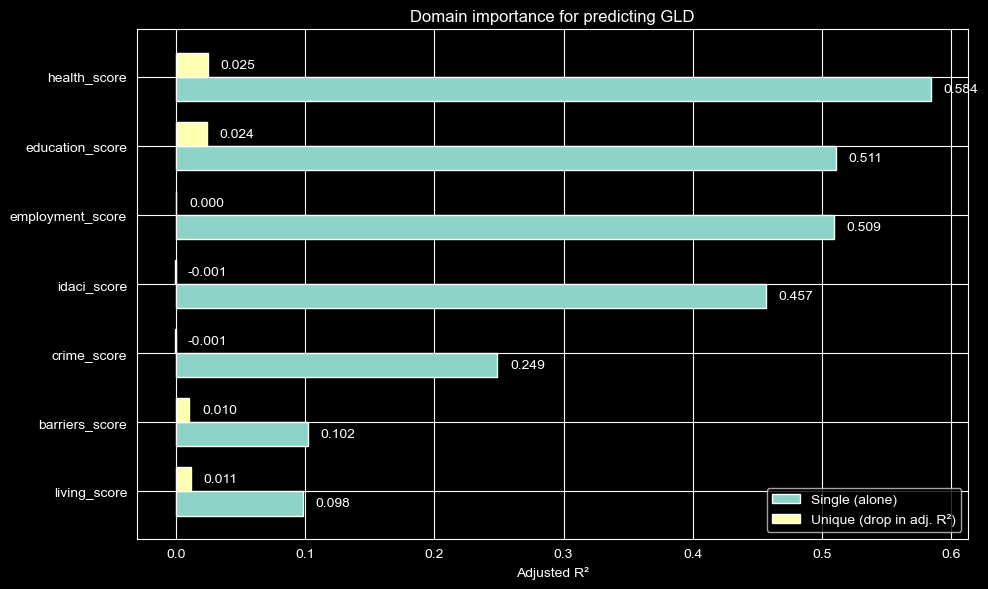

In [16]:
import numpy as np

results = pd.DataFrame({
    "Single": single_importance,
    "Unique": unique_importance
})
results = results.sort_values("Single", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results))
width = 0.35
ax.barh(x - width/2, results["Single"], width, label="Single (alone)")
ax.barh(x + width/2, results["Unique"], width, label="Unique (drop in adj. R²)")
for i, col in enumerate(results.index):
    ax.text(results.loc[col, "Single"] + 0.01, i - width/2, f'{results.loc[col, "Single"]:.3f}', va='center')
    ax.text(results.loc[col, "Unique"] + 0.01, i + width/2, f'{results.loc[col, "Unique"]:.3f}', va='center')
ax.set_yticks(x)
ax.set_yticklabels(results.index)
ax.set_xlabel("Adjusted R²")
ax.set_title("Domain importance for predicting GLD")
ax.legend()
plt.tight_layout()

### Part 1b: Residuals

The residuals tell us which districts are doing better or worse than deprivation alone would predict. Large positive residuals = better than expected; large negative = worse than expected.

In [17]:
df["residual"] = model_iod.resid

# Districts performing better than deprivation predicts
positive_resid = df.nlargest(10, "residual")[["lad_name", "imd_score", "gld_children_percent", "residual"]]

# Districts performing worse than deprivation predicts
negative_resid = df.nsmallest(10, "residual")[["lad_name", "imd_score", "gld_children_percent", "residual"]]

print(f"Districts performing better than expected based on deprivation:\n{positive_resid}")
print(f"Districts performing worse than expected based on deprivation:\n{negative_resid}")

Districts performing better than expected based on deprivation:
            lad_name  imd_score  gld_children_percent  residual
247  Isles of Scilly  -0.969986              5.962234  4.642474
22             Fylde  -0.490367              1.726675  1.772513
255   City of London  -0.633509              2.533589  1.658588
286   Waltham Forest   0.666419              1.539411  1.356227
174        Eastleigh  -1.194676              1.871586  1.308011
208  Epsom and Ewell  -1.363100              2.391046  1.304885
236       South Hams  -0.756946              1.834177  1.199250
41          Trafford  -0.463970              1.323292  1.169902
215        Tandridge  -0.983495              1.788891  1.154468
207        Elmbridge  -1.473276              2.435222  1.090415
Districts performing worse than expected based on deprivation:
                 lad_name  imd_score  gld_children_percent  residual
76                Lincoln   0.874626             -2.502306 -1.764953
125  South Cambridgeshire  -1.4

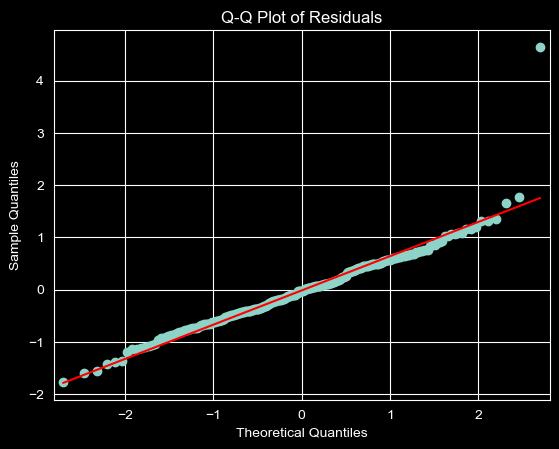

In [18]:
from statsmodels.graphics.gofplots import qqplot
qqplot(df["residual"], line="s")
plt.title("Q-Q Plot of Residuals")
plt.show()

### Part 2: Can early years provision explain the residuals?

The IoD domain model explains 62% of the variance in GLD (adj. R² = 0.622). To explore what else might matter, we bring in five measures of early years provision from the DfE's funded childcare data (January 2025):

- **eyp_takeup** — take-up rate of the universal entitlement (% of eligible 3–4 year olds registered)
- **ofsted_weighted_score** — quality of providers, weighted by Ofsted rating (4 = Outstanding, 1 = Inadequate)
- **sen_prevalence** — % of children with identified SEN
- **sen_ehc_rate** — of children with SEN, what % have an EHC Plan (formal support)
- **sen_early_identification_rate** — of children with SEN, what % were identified in Nursery (vs Reception)

These are at local authority level, so districts within the same LA share the same values. We regress out IMD from each factor first, so we're looking at the part of each factor that isn't just a proxy for deprivation.

In [19]:
with open(Path(PROJECT_ROOT / "sql" / "extra_factors.sql")) as f:
    query = f.read()

with sqlite3.connect(DATABASE_PATH) as conn:
    df_extra = pd.read_sql_query(query, conn, params=[202425])

print(df_extra)

      lad_code              lad_name new_la_code               la_name  \
0    E06000001            Hartlepool   E06000001            Hartlepool   
1    E06000002         Middlesbrough   E06000002         Middlesbrough   
2    E06000003  Redcar and Cleveland   E06000003  Redcar and Cleveland   
3    E06000004      Stockton-on-Tees   E06000004      Stockton-on-Tees   
4    E06000005            Darlington   E06000005            Darlington   
..         ...                   ...         ...                   ...   
282  E07000235         Malvern Hills   E10000034        Worcestershire   
283  E07000236              Redditch   E10000034        Worcestershire   
284  E07000237             Worcester   E10000034        Worcestershire   
285  E07000238              Wychavon   E10000034        Worcestershire   
286  E07000239           Wyre Forest   E10000034        Worcestershire   

     gld_children_percent  imd_score  eyp_takeup  ofsted_weighted_score  \
0               65.039062     35.037

In [20]:
extra_cols = ["eyp_takeup", "ofsted_weighted_score", "sen_prevalence", "sen_ehc_rate", "sen_early_identification_rate"]
print(f"Missing values:\n{df_extra[extra_cols].isna().sum()}")

mask = df_extra[["sen_ehc_rate", "sen_early_identification_rate"]].notna().all(axis=1)
df_extra = df_extra[mask]
df = df[mask]

df_extra[extra_cols] = df_extra[extra_cols].apply(zscore)

X = df_extra[extra_cols]
y = df["residual"]

if len(X) != len(y):
    raise ValueError("Mismatched lengths between features and target variable.")

print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Missing values:
eyp_takeup                       0
ofsted_weighted_score            0
sen_prevalence                   0
sen_ehc_rate                     1
sen_early_identification_rate    1
dtype: int64
Shape of X: (286, 5), Shape of y: (286,)


For each extra factor, we regress it against IMD and take the residuals. This gives us the part of each factor that varies independently of deprivation. We then use these "cleaned" factors to predict the GLD residuals from Part 1.

In [21]:
weights = df.loc[X.index, "children_count"]
X_residuals = pd.DataFrame()
imd = df.loc[X.index, "imd_score"]
for col in X.columns:
    m = sm.WLS(X[col], sm.add_constant(imd), weights=weights).fit()
    X_residuals[col] = m.resid

In [22]:
model_extra = sm.WLS(y, sm.add_constant(X_residuals), weights=weights).fit()
print(model_extra.summary())

                            WLS Regression Results                            
Dep. Variable:               residual   R-squared:                       0.036
Model:                            WLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.082
Date:                Thu, 28 May 2026   Prob (F-statistic):             0.0678
Time:                        17:39:56   Log-Likelihood:                -262.76
No. Observations:                 286   AIC:                             537.5
Df Residuals:                     280   BIC:                             559.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

After controlling for deprivation, only one provision factor significantly predicts the remaining variance:

- **sen_ehc_rate** (p = 0.002) — LAs where a higher proportion of SEN children have EHC Plans tend to have better GLD outcomes than their deprivation predicts. This may reflect more proactive or better-resourced SEN support systems.

The other four factors are not significant (all p > 0.30). The overall adj. R² is 0.019 — these provision measures explain very little of the variance left over after the IoD domains. This is unsurprising: the domain model already captures 62% of the variance, and the remaining 38% is likely driven by factors not available at this geographic level (e.g., individual school effectiveness, family characteristics, workforce qualifications).

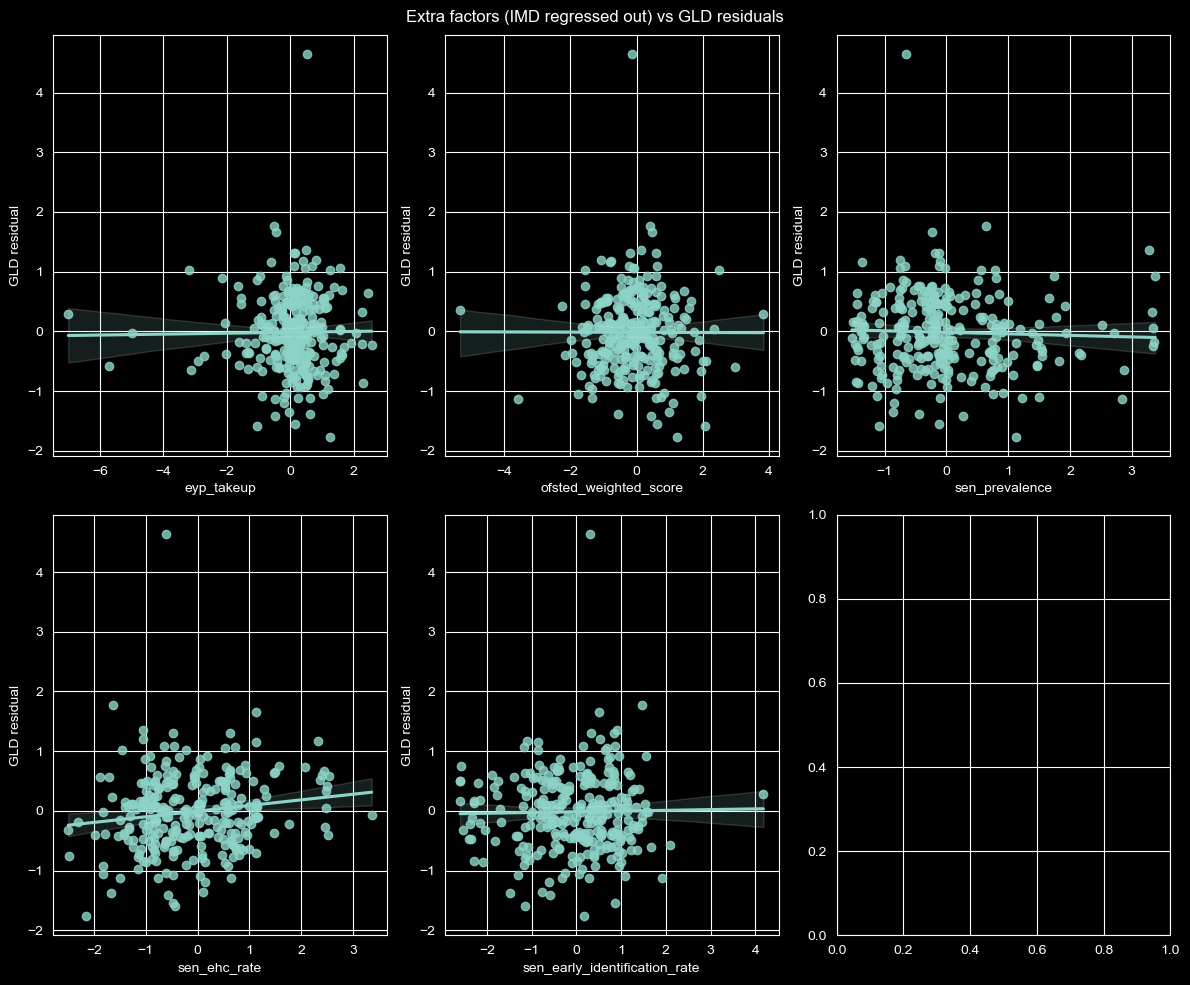

In [23]:
df_plot = X_residuals.copy()
df_plot["residual"] = y

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
for ax, col in zip(axes.flatten(), extra_cols):
    sns.regplot(data=df_plot, x=col, y="residual", ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel("GLD residual")
fig.suptitle("Extra factors (IMD regressed out) vs GLD residuals")
plt.tight_layout()
plt.show()



In [24]:
for col in extra_cols:
    fig = px.scatter(
        x=X_residuals[col],
        y=y,
        size=df.loc[X.index, "children_count"],
        hover_name=df.loc[X.index, "lad_name"],
        trendline="ols",
        labels={"x": col, "y": "GLD residual"},
        title=f"{col} vs GLD residual (point size = children count)"
    )
    fig.show()